# Shopper Spectrum: Customer Segmentation

## Day 2 - RFM Analysis and Customer Segmentation

### Objective
To segment customers based on Recency, Frequency, and Monetary (RFM) metrics using KMeans Clustering.

# 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

# 2. Load Dataset and Perform Cleaning

In [4]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")

df = df.dropna(subset=["CustomerID"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Shape:", df.shape)

Shape: (397884, 9)


# 3. Create RFM Features

In [5]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# 4. RFM Dataset Summary

In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


# 5. RFM Distribution Analysis

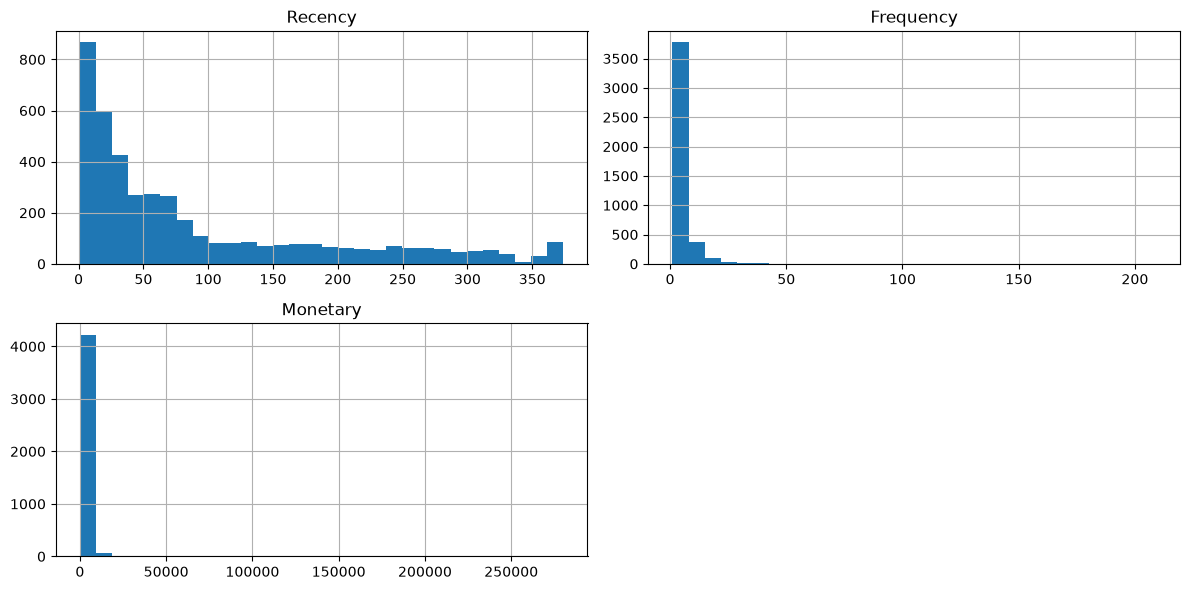

In [7]:
rfm.hist(
    figsize=(12,6),
    bins=30
)

plt.tight_layout()
plt.show()

### Observation

- Customer purchase frequency varies significantly.
- Some customers spend considerably more than others.
- Recent customers tend to be more valuable for business.
- RFM metrics will be used for customer segmentation.

# 6. Standardize RFM Features

In [8]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print(rfm_scaled.shape)

(4338, 3)


# 7. Elbow Method for Optimal Cluster Selection

In [9]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(
        kmeans.inertia_
    )

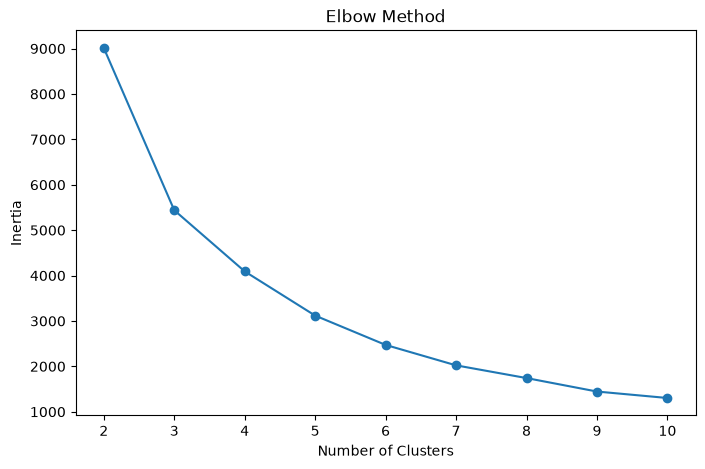

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

### Observation

- The elbow point helps determine the optimal number of clusters.
- The point where inertia reduction slows down is considered the best K value.

# 8. Silhouette Score Evaluation

In [11]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        rfm_scaled
    )

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(
        f"K={k} | Silhouette Score={score:.4f}"
    )

K=2 | Silhouette Score=0.8958
K=3 | Silhouette Score=0.5942
K=4 | Silhouette Score=0.6162
K=5 | Silhouette Score=0.6165
K=6 | Silhouette Score=0.5963
K=7 | Silhouette Score=0.5165
K=8 | Silhouette Score=0.5175
K=9 | Silhouette Score=0.4777
K=10 | Silhouette Score=0.4271


# 9. Customer Segmentation using KMeans

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


# 10. Cluster Distribution

In [13]:
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

# 11. Cluster Profiling

In [14]:
cluster_profile = rfm.groupby(
    "Cluster"
)[["Recency","Frequency","Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


# 12. Assign Business Labels to Customer Segments

In [15]:
cluster_mapping = {
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
}

rfm["Segment"] = rfm["Cluster"].map(
    cluster_mapping
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular
12347.0,2,7,4310.00,0,Occasional
12348.0,75,4,1797.24,0,Occasional
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,1,At-Risk


# 13. Segment Distribution

In [16]:
rfm["Segment"].value_counts()

Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64

# 14. Customer Segment Visualization

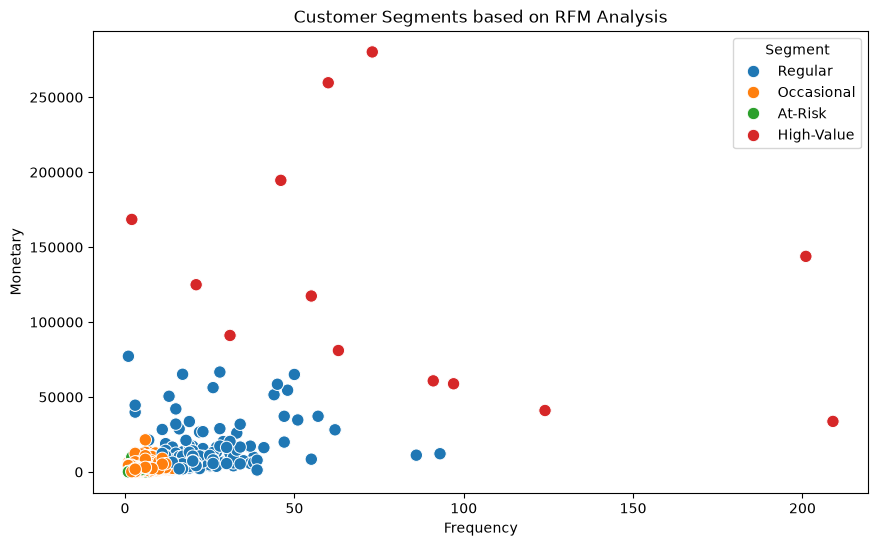

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    s=80
)

plt.title(
    "Customer Segments based on RFM Analysis"
)

plt.show()

# 15. Save Customer Segments

In [18]:
rfm.to_csv(
    "../outputs/customer_segments.csv"
)

print(
    "Customer Segments Saved"
)

Customer Segments Saved


In [19]:
joblib.dump(
    kmeans,
    "../models/kmeans.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print(
    "Models Saved Successfully"
)

Models Saved Successfully


### Observation

- Four customer segments were identified using KMeans clustering.
- High-Value customers are the most profitable and purchase frequently.
- Regular customers contribute consistently to revenue.
- Occasional customers purchase infrequently and spend moderately.
- At-Risk customers have not purchased recently and may require retention strategies.